In [190]:
import numpy as np 
import pandas as pd

In [191]:
df = pd.read_csv('fraud_oracle.csv')

## Analysis and Cleaning

In [192]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [193]:
df.shape

(15420, 33)

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [195]:
df.duplicated().sum()

np.int64(0)

In [196]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [197]:
df['Age'].describe()

count    15420.000000
mean        39.855707
std         13.492377
min          0.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

In [198]:
df['DayOfWeekClaimed'].value_counts()

DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
0               1
Name: count, dtype: int64

In [199]:
df['Days_Policy_Accident'].value_counts()

Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [200]:
df['Days_Policy_Claim'].value_counts()

Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64

In [201]:
(df['Age']==0).sum()

np.int64(320)

In [202]:
df = df[df['DayOfWeekClaimed'] != '0'].reset_index(drop=True)

In [203]:
df.shape

(15419, 33)

## EDA

In [204]:
df['FraudFound_P'].value_counts(normalize=True)

FraudFound_P
0    0.940139
1    0.059861
Name: proportion, dtype: float64

In [205]:
cat_cols = ['Make', 'AccidentArea', 'Sex', 'Fault', 'PolicyType', 'BasePolicy','AgeOfPolicyHolder']

for col in cat_cols:
    print(f"\n--- Fraud Rate by {col} ---")
    
    fraud_rate = df.groupby(col)['FraudFound_P'].mean() * 100
    print(fraud_rate.sort_values(ascending=False).round(2).astype(str) + '%')



--- Fraud Rate by Make ---
Make
Mecedes       25.0%
Accura        12.5%
Saturn       10.34%
Saab         10.19%
Ford          7.33%
Mercury       7.23%
BMW           6.67%
Honda         6.39%
Toyota        5.96%
Chevrolet     5.59%
Pontiac       5.55%
Mazda         5.23%
Nisson        3.33%
VW            2.83%
Dodge         1.83%
Lexus          0.0%
Porche         0.0%
Jaguar         0.0%
Ferrari        0.0%
Name: FraudFound_P, dtype: object

--- Fraud Rate by AccidentArea ---
AccidentArea
Rural    8.33%
Urban    5.72%
Name: FraudFound_P, dtype: object

--- Fraud Rate by Sex ---
Sex
Male      6.29%
Female    4.34%
Name: FraudFound_P, dtype: object

--- Fraud Rate by Fault ---
Fault
Policy Holder    7.89%
Third Party      0.88%
Name: FraudFound_P, dtype: object

--- Fraud Rate by PolicyType ---
PolicyType
Sport - Collision       13.79%
Utility - All Perils    12.06%
Sedan - All Perils      10.06%
Utility - Collision      10.0%
Sedan - Collision        6.88%
Sedan - Liability        0.7

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

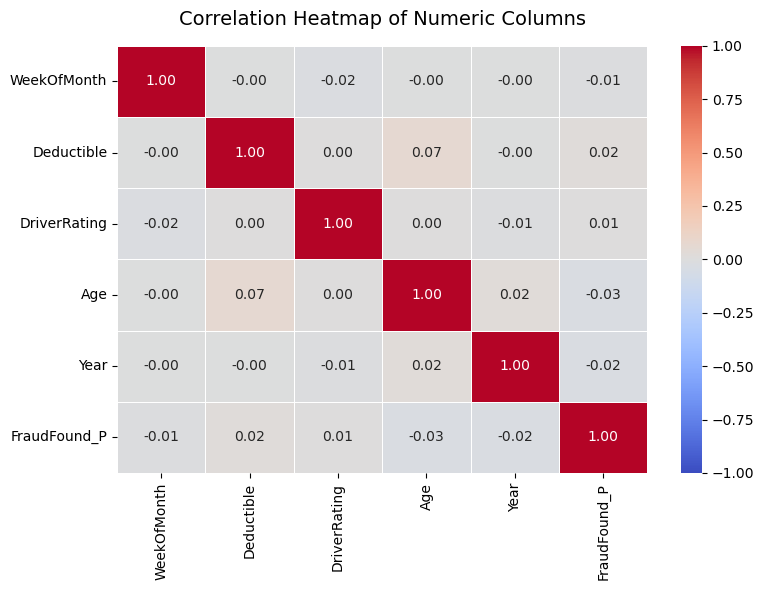

In [207]:
numeric_cols = ['WeekOfMonth', 'Deductible', 'DriverRating', 'Age', 'Year', 'FraudFound_P']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))


sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=-1, vmax=1,     
    linewidths=0.5       
)

plt.title('Correlation Heatmap of Numeric Columns', fontsize=14, pad=15)
plt.tight_layout()
plt.show()
 

In [208]:
numeric_cols = ['WeekOfMonth', 'Deductible', 'DriverRating', 'Age', 'Year', 'FraudFound_P']

fraud_corr = df[numeric_cols].corr()['FraudFound_P'].sort_values(ascending=False)

print("--- Correlation with FraudFound_P ---")
print(fraud_corr.round(4))


--- Correlation with FraudFound_P ---
FraudFound_P    1.0000
Deductible      0.0173
DriverRating    0.0073
WeekOfMonth    -0.0119
Year           -0.0248
Age            -0.0298
Name: FraudFound_P, dtype: float64


In [209]:
corr_matrix = df[numeric_cols].corr()
clean_summary = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))

print("--- Clean Correlation Summary Table ---")
print(clean_summary.dropna(how='all').round(4))


--- Clean Correlation Summary Table ---
              WeekOfMonth  Deductible  DriverRating     Age    Year  \
Deductible        -0.0040         NaN           NaN     NaN     NaN   
DriverRating      -0.0168      0.0039           NaN     NaN     NaN   
Age               -0.0049      0.0694        0.0016     NaN     NaN   
Year              -0.0039     -0.0012       -0.0139  0.0250     NaN   
FraudFound_P      -0.0119      0.0173        0.0073 -0.0298 -0.0248   

              FraudFound_P  
Deductible             NaN  
DriverRating           NaN  
Age                    NaN  
Year                   NaN  
FraudFound_P           NaN  


In [210]:
for col in ['PastNumberOfClaims','PoliceReportFiled','WitnessPresent']:
    print(df.groupby(col)['FraudFound_P'].mean())

PastNumberOfClaims
1              0.062133
2 to 4         0.053601
more than 4    0.033831
none           0.077913
Name: FraudFound_P, dtype: float64
PoliceReportFiled
No     0.060503
Yes    0.037383
Name: FraudFound_P, dtype: float64
WitnessPresent
No     0.060005
Yes    0.034483
Name: FraudFound_P, dtype: float64


In [211]:
df['Make'].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2800
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

## Feature Engineering

In [212]:
## Grouping Rare Maker as 'Other' which has value count <50

make_counts = df["Make"].value_counts()
rare_makes = make_counts[make_counts < 50].index
df["Make"] = df["Make"].replace(rare_makes, "Other")

In [213]:
# Imputing Age = 0 with POlicyHolders median age 

df["Age"] = df["Age"].replace(0, np.nan) ## imputing age = 0 as NAN so that i doesnt skew median

df["Age"] = df.groupby("AgeOfPolicyHolder")["Age"].transform(
    lambda x: x.fillna(x.median())
)

df["Age"] = df["Age"].fillna(df["Age"].median()) 

In [214]:
df['Age'].describe()

count    15419.000000
mean        40.665153
std         12.183889
min         16.000000
25%         31.000000
50%         39.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

In [215]:
# Ordinal Encoding for Ordered Categories

ordinal_cols = [
    "Days_Policy_Accident",
    "Days_Policy_Claim",
    "AgeOfVehicle",
    "AgeOfPolicyHolder",
    "PastNumberOfClaims",
    "NumberOfSuppliments",
    "AddressChange_Claim",
    "NumberOfCars",
] 

for col in ordinal_cols:
    df[col] = df[col].astype("category").cat.as_ordered()

In [216]:
# One-Hot Encoding for Nominal Categories

nominal_cols = [
    "Make",
    "AccidentArea",
    "Sex",
    "MaritalStatus",
    "Fault",
    "PolicyType",
    "VehicleCategory",
    "VehiclePrice",
    "PoliceReportFiled",
    "WitnessPresent",
    "AgentType",
    "BasePolicy",
    "Month",
    "DayOfWeek",
    "MonthClaimed",
    "DayOfWeekClaimed",
] 

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [217]:
if "PolicyNumber" in df.columns:
    df.drop(columns=["PolicyNumber"], inplace=True)

In [218]:
df.shape

(15419, 88)

## Modelling and Evaluation

In [219]:
from sklearn.model_selection import train_test_split

In [220]:
x = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

In [221]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, stratify=y, random_state=42)

In [222]:
from sklearn.preprocessing import StandardScaler

In [223]:
scaler = StandardScaler()

In [224]:
print(x_train.isnull().sum().sum())
print(x_train.dtypes.value_counts())

0
bool        72
int64        6
float64      1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [225]:
cat_cols = x_train.select_dtypes(include='category').columns
for col in cat_cols:
    x_train[col] = x_train[col].cat.codes
    x_test[col] = x_test[col].cat.codes

In [226]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [227]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

#### Base Model = Logistic Regression

In [228]:
LR = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [229]:
LR.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [230]:
y_pred_lr = LR.predict(x_test_scaled)
y_proba_lr = LR.predict_proba(x_test_scaled)[:,1]

In [231]:
print(classification_report(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))
print("ROC-AUC Score : ", roc_auc_score(y_test,y_proba_lr))
print("PR-AUC Score : ", average_precision_score(y_test,y_proba_lr))

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.88      0.23       185

    accuracy                           0.65      3084
   macro avg       0.56      0.76      0.50      3084
weighted avg       0.94      0.65      0.74      3084

[[1833 1066]
 [  22  163]]
ROC-AUC Score :  0.8108313211452225
PR-AUC Score :  0.16445084192431783


#### Random Forest

In [232]:
from sklearn.ensemble import RandomForestClassifier

In [233]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)

In [234]:
rf.fit(x_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [235]:
y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:,1]

In [236]:
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print("ROC-AUC Score : ", roc_auc_score(y_test,y_proba_rf))
print("PR-AUC Score : ", average_precision_score(y_test,y_proba_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084

[[2899    0]
 [ 184    1]]
ROC-AUC Score :  0.8369036853341787
PR-AUC Score :  0.24172581857321795


In [237]:
probs = rf.predict_proba(x_test)[:,1]
y_pred_thresh = (probs >= 0.2).astype(int)   
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh)) 

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2899
           1       0.31      0.19      0.23       185

    accuracy                           0.93      3084
   macro avg       0.63      0.58      0.60      3084
weighted avg       0.91      0.93      0.92      3084

[[2821   78]
 [ 150   35]]


In [238]:
probs = rf.predict_proba(x_test)[:,1]
y_pred_thresh = (probs >= 0.3).astype(int)   
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh)) 

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.42      0.05      0.10       185

    accuracy                           0.94      3084
   macro avg       0.68      0.52      0.53      3084
weighted avg       0.91      0.94      0.92      3084

[[2885   14]
 [ 175   10]]


In [239]:
probs = rf.predict_proba(x_test)[:,1]
y_pred_thresh = (probs >= 0.1).astype(int)   
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh)) 

              precision    recall  f1-score   support

           0       0.97      0.78      0.87      2899
           1       0.17      0.68      0.27       185

    accuracy                           0.78      3084
   macro avg       0.57      0.73      0.57      3084
weighted avg       0.93      0.78      0.83      3084

[[2266  633]
 [  59  126]]


### We are taking 0.2 as threhold for Random Forest Classifier So final report will be :-

In [240]:
probs = rf.predict_proba(x_test)[:,1]
y_pred_thresh = (probs >= 0.2).astype(int)   
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh)) 

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2899
           1       0.31      0.19      0.23       185

    accuracy                           0.93      3084
   macro avg       0.63      0.58      0.60      3084
weighted avg       0.91      0.93      0.92      3084

[[2821   78]
 [ 150   35]]


## XGBoost

In [241]:
from xgboost import XGBClassifier

In [242]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos_weight = neg / pos

In [243]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

In [244]:
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [246]:
probs_xgb = xgb.predict_proba(x_test)[:, 1]

In [247]:
# checking multiple thresholds like we did for RF
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (probs_xgb >= t).astype(int)
    print(f"--- threshold {t} ---")
    print(classification_report(y_test, y_pred_t))

print("ROC-AUC:", roc_auc_score(y_test, probs_xgb))
print("PR-AUC:", average_precision_score(y_test, probs_xgb))

--- threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2899
           1       0.17      0.74      0.28       185

    accuracy                           0.77      3084
   macro avg       0.58      0.76      0.57      3084
weighted avg       0.93      0.77      0.83      3084

--- threshold 0.4 ---
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      2899
           1       0.18      0.65      0.29       185

    accuracy                           0.81      3084
   macro avg       0.58      0.73      0.59      3084
weighted avg       0.93      0.81      0.85      3084

--- threshold 0.5 ---
              precision    recall  f1-score   support

           0       0.97      0.87      0.91      2899
           1       0.20      0.52      0.29       185

    accuracy                           0.84      3084
   macro avg       0.58      0.69      0.60      3084
weighted

##### XGBoost at a 0.5 threshold is selected as the final model, offering superior fraud detection with 52% recall and 0.20 precision compared to Random Forest's 19% recall at 0.31 precision. While maintaining comparable overall metrics to RF, the XGBoost model provides better real-world fraud prevention, balancing business risk and false alarm rates.